# Analysis of the raw results data (arithmentic dataset)

In [1]:
!pwd

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from analysis import load_experiment_data, plot_general_accuracy, plot_intervention_success_rate, plot_clique_sizes, plot_outcome_breakdown


/home/vic/files/GenMod/Interchange/analysis/result_analysis


In [2]:
RESULTS_DIR = "../results"

df = load_experiment_data(RESULTS_DIR)

# look at the (unique) abstract variables and layers we loaded
print("High nodes (abstract variables):", df['high_node'].unique())
print("Low nodes (neural layers):", df['low_node'].unique())

Loaded 9764928 total intervention experiments.
High nodes (abstract variables): ['sign' 'result' 'x_value' 'y_value' 'op']
Low nodes (neural layers): ['bert_layer_10' 'bert_layer_3' 'bert_layer_9' 'bert_layer_4'
 'bert_layer_5' 'bert_layer_0' 'bert_layer_8' 'bert_layer_2'
 'bert_layer_6' 'bert_layer_1' 'bert_layer_7']


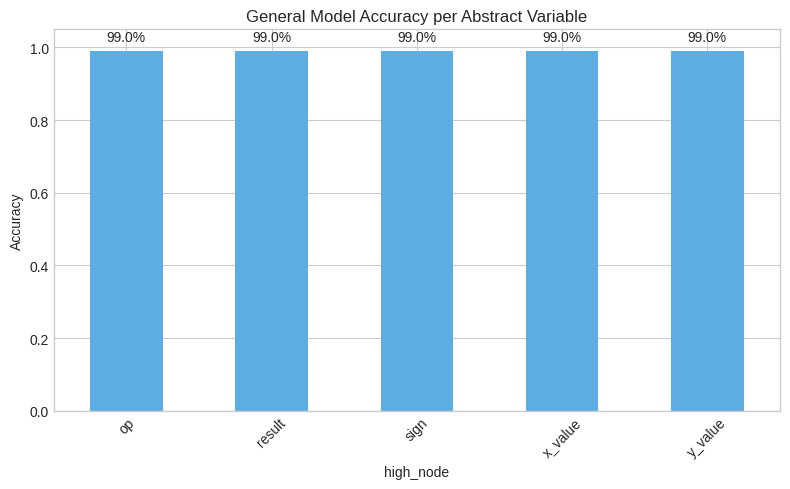

In [3]:
plot_general_accuracy(df, "arithmetic")

Understanding the Baseline: General Model Accuracy

This plot establishes the baseline performance of our neural network *before* any causal interventions (representation swaps) are applied. It demonstrates that the model successfully classifies the correct sign (positive, negative, or zero) of the base arithmetic problems **99.0%** of the time.  yippy!

You will notice that the accuracy is identical across all five abstract variables (`op`, `result`, `sign`, `x_value`, and `y_value`). The general accuracy evaluates (from what I understand) the model's original, untouched performance on the exact same sampled test set. The graph here just groups these identical baseline results by the variable that will be intervened upon in the subsequent experiments. 

Ultimately, this near-perfect accuracy proves that the model has thoroughly mastered the arithmetic task, making it a valid candidate for us to dissect and analyze using causal abstraction.

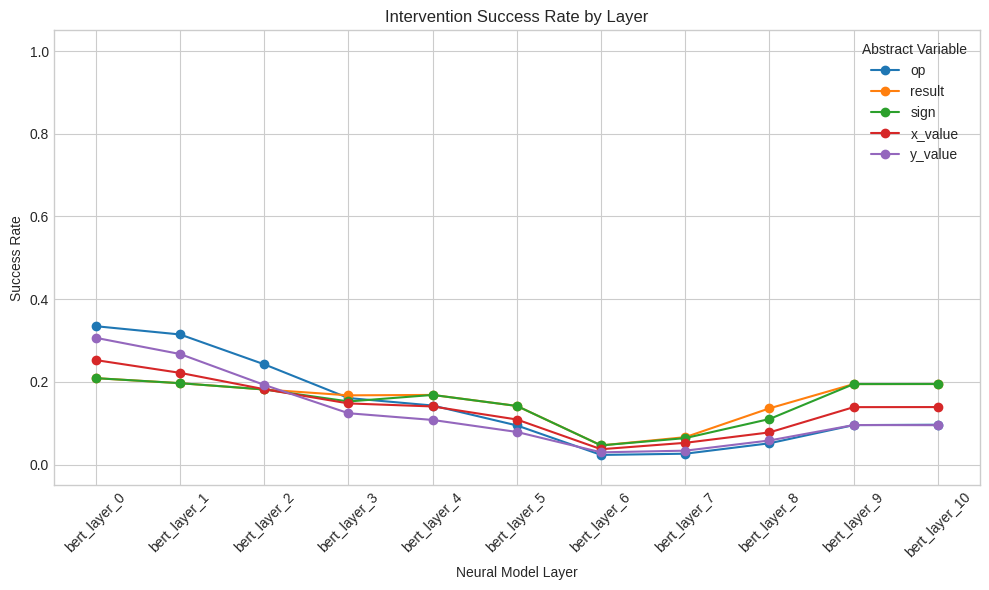

In [4]:

plot_intervention_success_rate(df, "arithmetic")

Understanding Causal Interventions: Success Rate by Layer

This plot visualizes the Intervention Success Rate across the different layers of our BERT model. To calculate this, we take a neural representation from a "Source" math problem and forcefully inject it into a "Base" math problem to see if the model's final prediction changes exactly as our ideal causal model dictates. According to the paper, an intervention is considered "successful" if the output of the intervened neural network perfectly matches the output of the intervened causal model. Furthermore, to isolate the causal impact, the experiment specifically looks for "impactful" pairs—meaning the intervention was supposed to actually change the output.  

At first glance, the success rates looks quite low (peaking around 35% and dropping below 5% in the middle layers). metric represents the average success across all randomly paired examples. Forcefully swapping internal representations between random math problems usually breaks the network's delicate internal state, driving the average success rate down. 

The trends across the layers reveal how the model processes the equation sequentially: 

* **Early Layers (0-1):** The operator (`op`) has its highest success rate here. This may indicate that the network immediately reads, encodes, and isolates the concept of the mathematical operator (the `+` or `-` symbol) at the very beginning of its process. It is very easy to swap a + for a - at Layer 0 and get the correct new answer!

* **Middle Layers (5-7):** Success rates dip to their lowest points across all variables. The representations here are likely highly entangled as the Transformer attention heads mix the numbers and operators together to perform the calculation.
* **Late Layers (8-10):** The `result` and `sign` variables begin to rise again. As the model approaches its final output, it disentangles its internal math and firmly locks in the final predicted sign right before passing it to the classification head.


ValueError: 'uppper left' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

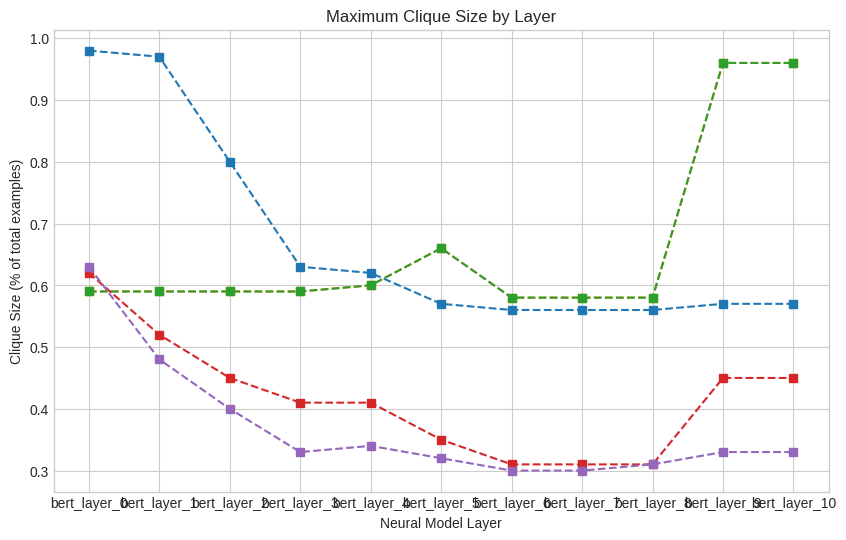

In [5]:

plot_clique_sizes(df, "arithmetic")

Maximum Clique Size by Layer

I would say this plot represents the core discovery of our causal abstraction analysis. In this context, a "clique" is a specific subset of our dataset where the neural network's internal representations perfectly and symmetrically mimic our ideal, high-level math rules. The larger the clique percentage, the stronger the proof that the model has learned a clean, systematic algorithm for that variable. 

This graph reveals exactly how the model processes the arithmetic step-by-step:

* **Immediate Reading (`op`):** The operator variable starts with a massive clique size of nearly 98% at Layer 0. This proves the network immediately reads, isolates, and encodes the mathematical operator (`+` or `-`) right at the input stage before doing any heavy lifting.
* **The Fused Calculation (`result` and `sign`):** The coolest insight is that the lines for the exact numerical `result` (orange) and the final `sign` classification (green) perfectly overlap. Furthermore, they don't peak in the middle of the network; they spike dramatically to over 95% at the very end (Layers 9 and 10). This indicates that the model did not learn to calculate the exact integer answer first and then separately determine its sign. Because it was only graded on the final classification, it optimized its internal circuitry to fuse the mathematical computation and the sign prediction into a single, highly efficient step right before the output.
* **Entangled Inputs (`x_value` and `y_value`):** The individual numbers start with moderate structure but dip significantly in the middle layers. This visualizes the "mixing" phase, where the network's attention heads probably entangle the inputs together to actually perform the math.

Cool Insight maybe:

In this evaluation of Bert model trained on basic arithmetic, the model demonstrates a near-perfect 99.0% accuracy on the data set tested, proving it successfully mastered the classification task. However, applying interchange interventions reveals that the network's internal "thought process" uses a uniquely optimized algorithmic shortcut. While the model exhibits strict, human-like logic at the very beginning of the process (strongly isolating the math operator (op) at Layer 0) its later layers blur the lines of traditional math (we compute the final number, in our case the result variable, and then decide if it is positive or negative). The perfectly overlapping clique sizes for the exact result and the final sign indicate that the model does not sequentially compute the exact number and then check its sign (I assume if it did, the results cliquesize would increase in the middle). Instead, because the network was solely graded on outputting the final classification, it optimized its internal workings to fuse the numerical calculation and the sign prediction into a single, highly efficient step at the end of the network: probably something like if x_value is positive and op is + then positive sign for the result.

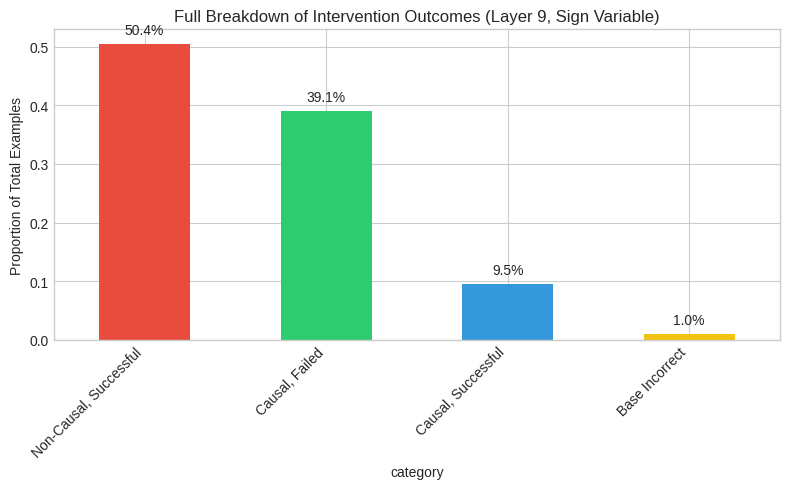

In [ ]:
plot_outcome_breakdown(df, "arithmetic")